# Experiment 3 -- aggregate and plot: complementary multi-source transfer

Reads every per-task CSV written by `run_experiment3.py` into
`Results_simulation/experiment3/raw/` (one file per seed, 6 rows -- one
per method), aggregates the Monte Carlo mean +/- SE of the overall and
pairwise-contrast errors, and reproduces the qualitative-pattern table
and bar chart from `transfer_clustering_simulation_plan.pdf` Section 5.10.

Run this after the SLURM array in
`Slurm_Scripts/experiment3_complementary/` has finished (or partially
finished).

In [1]:
import sys, os, glob

# Hardcoded (rather than relative to "..") because the kernel's cwd isn't
# guaranteed to be this notebook's directory -- e.g. VS Code's Jupyter
# extension often starts kernels from the workspace root instead. Mirrors
# the PROJECT_ROOT convention already used in Slurm_Scripts/*/run_*.sh and
# experiment1_01_aggregate_and_plot.ipynb.
PROJECT_ROOT = "/home/nandy.15/Research/Transfer_clustering"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "Experiments_Script"))

# The figure below uses matplotlib's text.usetex=True, which shells out to
# `latex`/`dvipng`. Hardcoded (rather than relying on `module load texlive`
# having been run in the launching shell) because the Jupyter kernel's PATH
# is whatever VS Code/Jupyter started with -- it won't see a module loaded
# after the fact. Matches the cluster's `module show texlive/2025`.
TEXLIVE_BIN = "/opt/lmod/texlive/2025/bin/x86_64-linux"
if TEXLIVE_BIN not in os.environ["PATH"].split(os.pathsep):
    os.environ["PATH"] = TEXLIVE_BIN + os.pathsep + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
RAW_DIR = os.path.join(PROJECT_ROOT, "Results_simulation", "experiment3", "raw")
COMBINED_DIR = os.path.join(PROJECT_ROOT, "Results_simulation", "experiment3", "combined")
os.makedirs(COMBINED_DIR, exist_ok=True)

paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
print(f"Found {len(paths)} raw result files")
assert paths, f"No CSVs found in {RAW_DIR} -- has the SLURM array finished any tasks yet?"

df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
df.head(10)

Found 100 raw result files


,seed,method,error_overall,error_12,error_13,error_23,branch,D0_used
0,0,target_only,0.515,0.283582,0.338346,0.428571,target,NaN
1,0,source1_only,0.245,0.029851,0.218045,0.150376,source,NaN
2,0,source2_only,0.435,0.447761,0.195489,0.203008,source,NaN
3,0,combined_sources,0.165,0.059701,0.135338,0.112782,source,NaN
4,0,pooled,0.220,0.059701,0.195489,0.135338,NaN,NaN
5,0,adaptive,0.515,0.283582,0.338346,0.428571,target,0.435462
6,1,target_only,0.490,0.208955,0.413534,0.293233,target,NaN
7,1,source1_only,0.265,0.059701,0.210526,0.187970,source,NaN
8,1,source2_only,0.490,0.425373,0.255639,0.308271,source,NaN
9,1,combined_sources,0.205,0.067164,0.142857,0.165414,source,NaN


In [3]:
METHOD_ORDER = ["target_only", "source1_only", "source2_only", "combined_sources", "pooled", "adaptive"]
METHOD_LABELS = {
    "target_only": "Target-only",
    "source1_only": "Source-1-only",
    "source2_only": "Source-2-only",
    "combined_sources": "Combined sources",
    "pooled": "Pooled",
    "adaptive": "Adaptive",
}
ERROR_COLS = ["error_overall", "error_12", "error_13", "error_23"]

# Sanity check: how many seeds actually landed per method? If well short
# of N_SEEDS in run_experiment3.py, the array job hasn't finished (or some
# tasks failed -- check Slurm_Scripts/.../Error_Messages).
df.groupby("method")["seed"].nunique().reindex(METHOD_ORDER)

method
target_only         100
source1_only        100
source2_only        100
combined_sources    100
pooled              100
adaptive            100
Name: seed, dtype: int64

In [4]:
summary = df.groupby("method")[ERROR_COLS].agg(["mean", lambda s: s.std(ddof=1) / np.sqrt(len(s))])
summary.columns = [f"{col}_{stat}" for col, stat in
                   zip([c for c in ERROR_COLS for _ in range(2)], ["mean", "se"] * len(ERROR_COLS))]
summary = summary.reindex(METHOD_ORDER)
summary.to_csv(os.path.join(COMBINED_DIR, "experiment3_summary.csv"))
summary

,error_overall_mean,error_overall_se,error_12_mean,error_12_se,error_13_mean,error_13_se,error_23_mean,error_23_se
method,,,,,,,,
target_only,0.50285,0.005535,0.268284,0.006779,0.369925,0.005439,0.368271,0.005394
source1_only,0.25740,0.004492,0.068209,0.002253,0.194286,0.004626,0.192256,0.004715
source2_only,0.49020,0.003494,0.442687,0.002600,0.259850,0.004385,0.264361,0.004075
combined_sources,0.16280,0.002459,0.053060,0.001733,0.122256,0.002817,0.122481,0.002931
pooled,0.23565,0.003053,0.057239,0.001985,0.188647,0.003865,0.165714,0.002961
adaptive,0.36250,0.016698,0.174627,0.010866,0.267368,0.012197,0.268722,0.012977


## Qualitative pattern table (Sec 5.10)

A checkmark means the method's mean error on that contrast is below
`CHECK_THRESHOLD` (a coin-flip-relative cutoff, not a formal test) --
purely for comparing against the paper's expected pattern table, not a
substitute for the numeric `summary` table above.

In [5]:
CHECK_THRESHOLD = 0.15

pattern = pd.DataFrame(index=METHOD_ORDER, columns=["(1,2)", "(1,3)", "(2,3)"])
for method in METHOD_ORDER:
    for col, err_col in zip(["(1,2)", "(1,3)", "(2,3)"], ["error_12", "error_13", "error_23"]):
        mean_err = summary.loc[method, f"{err_col}_mean"]
        pattern.loc[method, col] = "\u2713" if mean_err < CHECK_THRESHOLD else "\u2717"
pattern.index = [METHOD_LABELS[m] for m in pattern.index]
pattern

,"(1,2)","(1,3)","(2,3)"
Target-only,✗,✗,✗
Source-1-only,✓,✗,✗
Source-2-only,✗,✗,✗
Combined sources,✓,✓,✓
Pooled,✓,✗,✗
Adaptive,✗,✗,✗


## Figure: error by method and contrast

Grouped bar chart, one group per contrast (overall, (1,2), (1,3), (2,3)),
one bar per method with a fixed color (never reassigned across groups),
SE error bars.

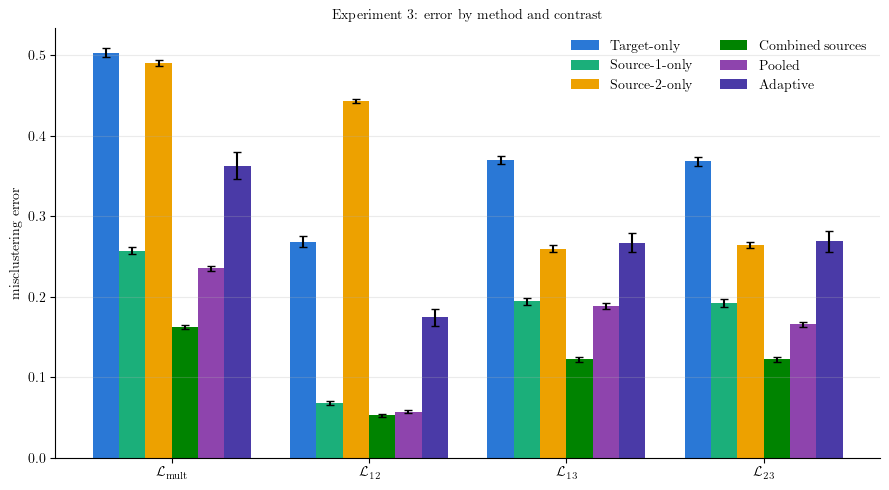

In [6]:
METHOD_COLORS = {
    "target_only": "#2a78d6",
    "source1_only": "#1baf7a",
    "source2_only": "#eda100",
    "combined_sources": "#008300",
    "pooled": "#8e44ad",
    "adaptive": "#4a3aa7",
}
GROUP_LABELS = [r"$\mathcal{L}_{\mathrm{mult}}$", r"$\mathcal{L}_{12}$", r"$\mathcal{L}_{13}$", r"$\mathcal{L}_{23}$"]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

n_methods = len(METHOD_ORDER)
x = np.arange(len(ERROR_COLS))
width = 0.8 / n_methods

fig, ax = plt.subplots(figsize=(9, 5))
for i, method in enumerate(METHOD_ORDER):
    means = [summary.loc[method, f"{c}_mean"] for c in ERROR_COLS]
    ses = [summary.loc[method, f"{c}_se"] for c in ERROR_COLS]
    offset = (i - (n_methods - 1) / 2) * width
    ax.bar(x + offset, means, width, yerr=ses, capsize=3,
           label=METHOD_LABELS[method], color=METHOD_COLORS[method])

ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS)
ax.set_ylabel("misclustering error")
ax.set_title("Experiment 3: error by method and contrast")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(COMBINED_DIR, "experiment3_bars.pdf"), bbox_inches="tight")
plt.show()

## Diagnostic: calibrated D0 stability (adaptive method only)

In [7]:
d0 = df[df["method"] == "adaptive"].copy()
d0["D0_used"] = pd.to_numeric(d0["D0_used"], errors="coerce")
d0["D0_used"].agg(["mean", "std", "count"])

mean       0.438941
std        0.005628
count    100.000000
Name: D0_used, dtype: float64